In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from urllib.parse import urlparse, parse_qs, parse_qsl
import seaborn as sns
import numpy as np
import tldextract
from wordcloud import WordCloud
from collections import Counter
from pandarallel import pandarallel

pandarallel.initialize(progress_bar=True)

tqdm.pandas()

benign_path = '../datasets/benign.csv'
malicious_path = '../datasets/malicious.csv'

INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
benign_df = pd.read_csv(benign_path, index_col=0)

benign_df

,url
0,https://royal-lab.net
1,https://creepypastafromthecrypt.blogspot.com
2,https://www.gosnowmass.com
3,https://heilsarmee.ch
4,https://cineten.com
...,...
3179080,https://csonline2.net/servers
3179081,https://www.aallnet.org/education-training/in-...
3179082,https://www.disney.es/peliculas/toy-story-5
3179083,https://honari.com/candleCal


In [3]:
malicious_df = pd.read_csv(malicious_path, index_col=0)

malicious_df

,url
0,http://rgrshousnodbeuabgrhr.net
1,http://144.202.27.199/index.html
2,https://bt-102738.weeblysite.com
3,http://help-meta-id-604149.0320189.com
4,http://bankofamerica.nsecurity.online/bankofam...
...,...
1118055,https://vaneldangueldase.web.app
1118056,http://fbnotify-h43sls41f.liftcentr.uz/profile...
1118057,https://authentifizierung.bkinginf.shop/cli/?p...
1118058,http://117.209.16.14:54236/bin.sh


In [ ]:
overlapping_urls = set(benign_df['url']) & set(malicious_df['url'])

print(len(overlapping_urls))

0


set()

In [11]:
# removing overlapping urls
benign_df.drop(benign_df[benign_df['url'].isin(overlapping_urls)].index, inplace=True)
malicious_df.drop(malicious_df[malicious_df['url'].isin(overlapping_urls)].index, inplace=True)

benign_df.reset_index(drop=True, inplace=True)
malicious_df.reset_index(drop=True, inplace=True)

In [ ]:
# benign_df.to_csv('../datasets/benign.csv')

# malicious_df.to_csv('../datasets/malicious.csv')

In [14]:
benign_df['scheme'] = benign_df['url'].progress_apply(lambda url: urlparse(url).scheme)
malicious_df['scheme'] = malicious_df['url'].progress_apply(lambda url: urlparse(url).scheme)

 23%|██▎       | 729281/3179085 [00:07<00:24, 101663.75it/s]

100%|██████████| 1118060/1118060 [00:09<00:00, 116018.60it/s]


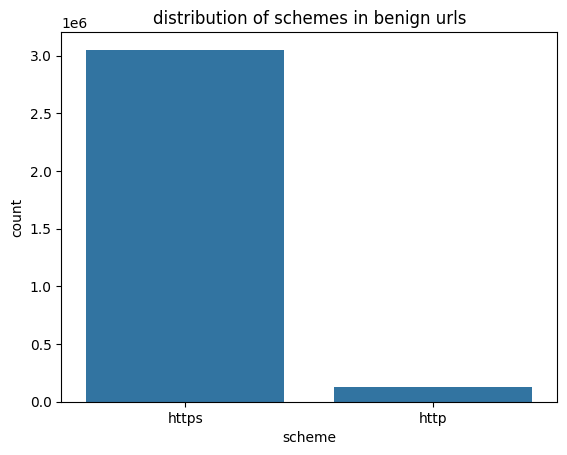

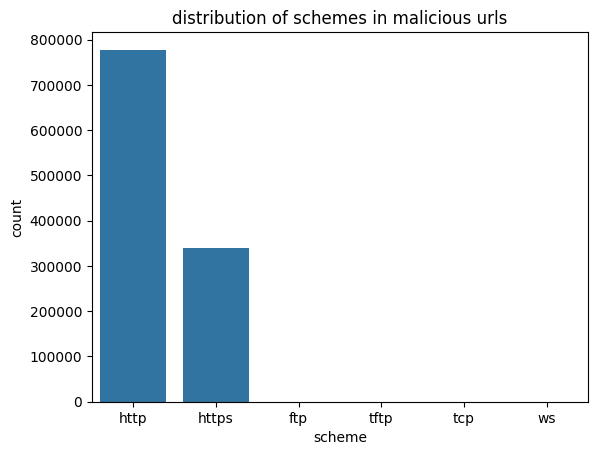

In [15]:
sns.countplot(data=benign_df, x='scheme')
plt.title('distribution of schemes in benign urls')
plt.show()

sns.countplot(data=malicious_df, x='scheme')
plt.title('distribution of schemes in malicious urls')
plt.show()

In [16]:
benign_df['path_length'] = benign_df['url'].progress_apply(lambda url: len(urlparse(url).path.split('/')) - 1)
malicious_df['path_length'] = malicious_df['url'].progress_apply(lambda url: len(urlparse(url).path.split('/')) - 1)

100%|██████████| 1118060/1118060 [00:10<00:00, 105740.83it/s]


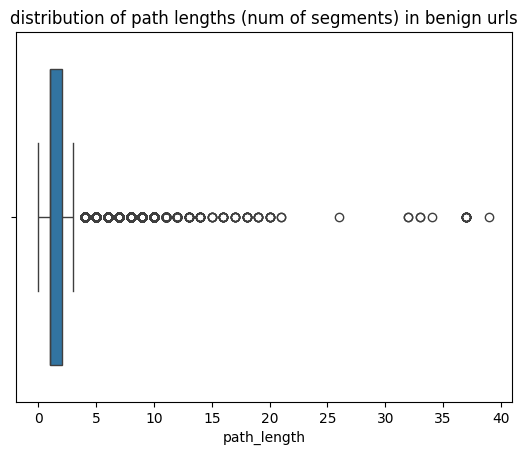

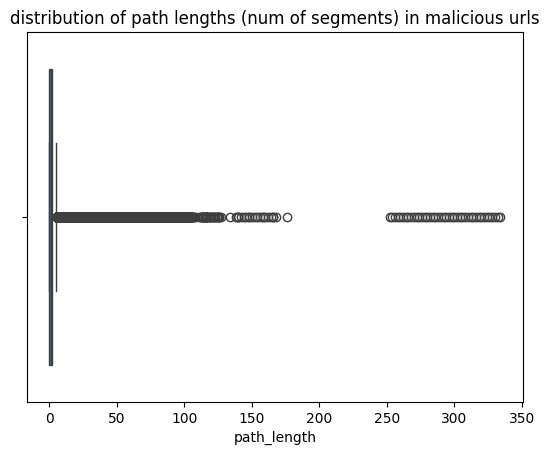

In [244]:
sns.boxplot(data=benign_df, x='path_length')
# plt.yscale('log')
plt.title('distribution of path lengths (num of segments) in benign urls')
plt.show()

sns.boxplot(data=malicious_df, x='path_length')
# plt.yscale('log')
plt.title('distribution of path lengths (num of segments) in malicious urls')
plt.show()

In [18]:
benign_df['path_len'] = benign_df['url'].progress_apply(lambda url: len(urlparse(url).path))
malicious_df['path_len'] = malicious_df['url'].progress_apply(lambda url: len(urlparse(url).path))

100%|██████████| 1118060/1118060 [00:09<00:00, 120658.41it/s]


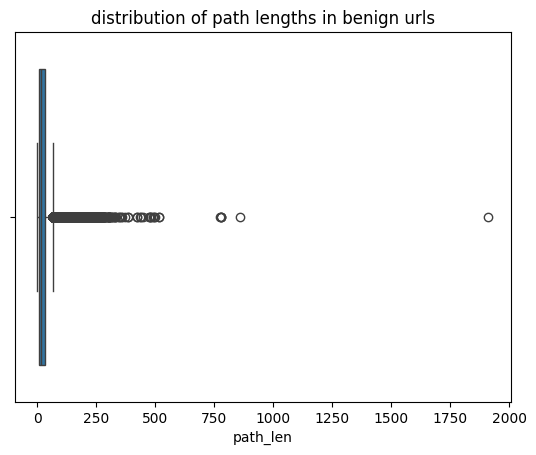

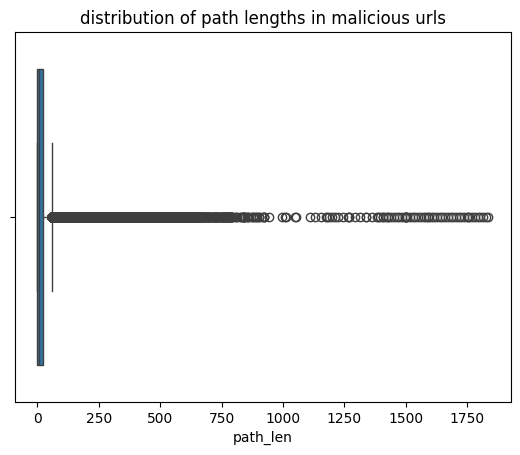

In [19]:
sns.boxplot(data=benign_df, x='path_len')
# plt.yscale('log')
plt.title('distribution of path lengths in benign urls')
plt.show()

sns.boxplot(data=malicious_df, x='path_len')
# plt.yscale('log')
plt.title('distribution of path lengths in malicious urls')
plt.show()

In [20]:
benign_df['query_length'] = benign_df['url'].progress_apply(lambda url: len(parse_qs(urlparse(url).query)))
malicious_df['query_length'] = malicious_df['url'].progress_apply(lambda url: len(parse_qs(urlparse(url).query)))

100%|██████████| 1118060/1118060 [00:12<00:00, 90476.27it/s] 


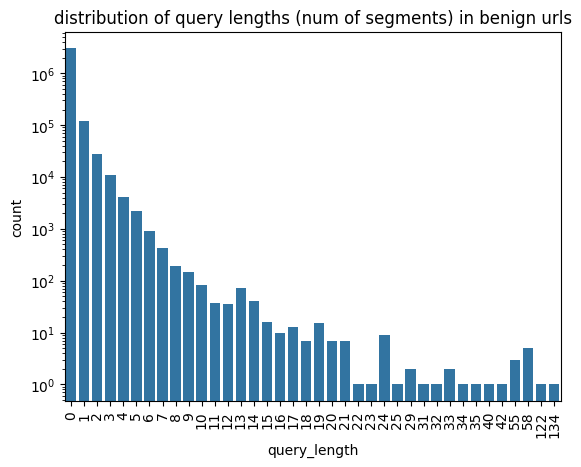

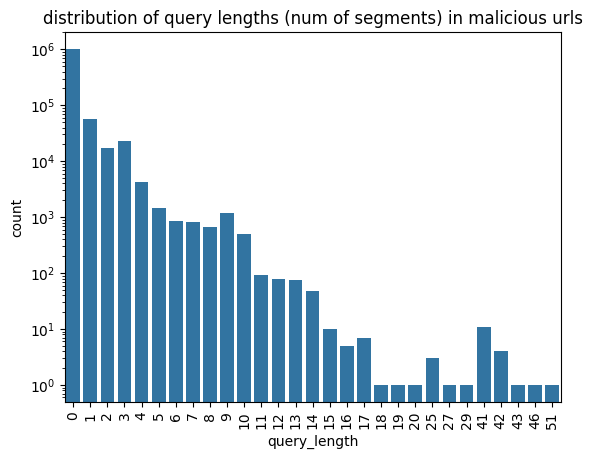

In [21]:
sns.countplot(data=benign_df, x='query_length')
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of query lengths (num of segments) in benign urls')
plt.show()

sns.countplot(data=malicious_df, x='query_length')
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of query lengths (num of segments) in malicious urls')
plt.show()

In [22]:
benign_df['query_len'] = benign_df['url'].progress_apply(lambda url: len(urlparse(url).query))
malicious_df['query_len'] = malicious_df['url'].progress_apply(lambda url: len(urlparse(url).query))

100%|██████████| 1118060/1118060 [00:09<00:00, 117852.78it/s]


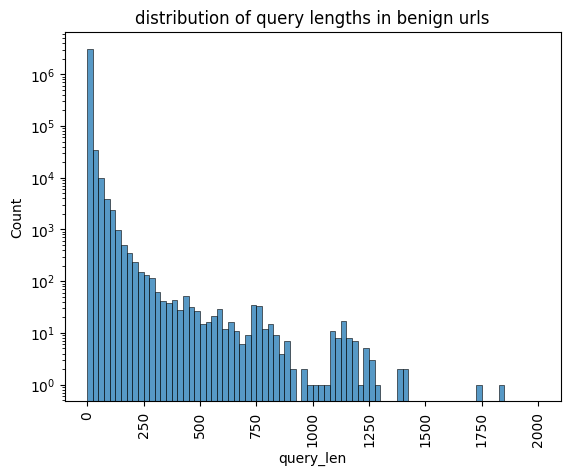

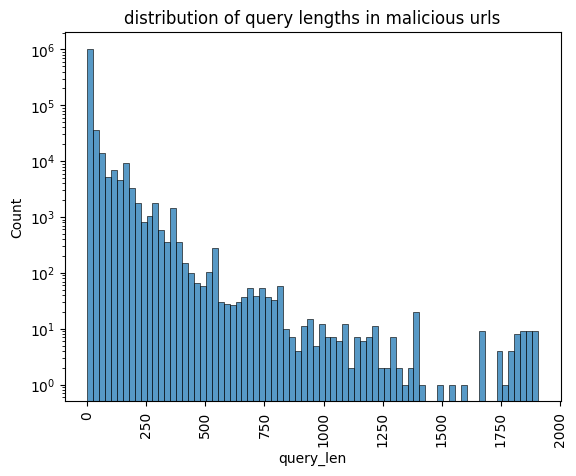

In [237]:
sns.histplot(data=benign_df, x='query_len', binrange=[0, 2000], binwidth=25)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of query lengths in benign urls')
plt.show()

sns.histplot(data=malicious_df, x='query_len', binwidth=25)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of query lengths in malicious urls')
plt.show()

In [24]:
benign_df['max_query_len'] = benign_df['url'].progress_apply(lambda url: max([len(''.join(query_val)) for query_key, query_val in parse_qs(urlparse(url).query).items()], default=0))
malicious_df['max_query_len'] = malicious_df['url'].progress_apply(lambda url: max([len(''.join(query_val)) for query_key, query_val in parse_qs(urlparse(url).query).items()], default=0))

100%|██████████| 1118060/1118060 [00:12<00:00, 92984.32it/s] 


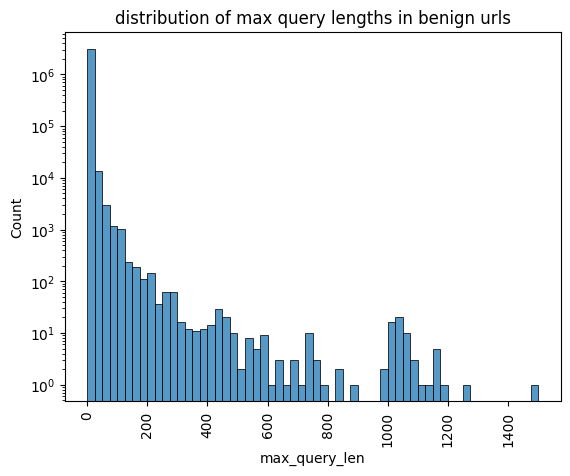

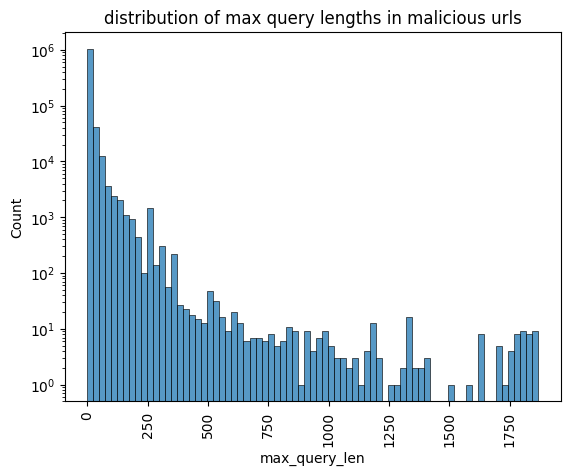

In [218]:
sns.histplot(data=benign_df, x='max_query_len', binrange=[0, 1500], binwidth=25)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of max query lengths in benign urls')
plt.show()

sns.histplot(data=malicious_df, x='max_query_len', binwidth=25)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of max query lengths in malicious urls')
plt.show()

In [26]:
benign_df['fragment_len'] = benign_df['url'].progress_apply(lambda url: len(urlparse(url).fragment))
malicious_df['fragment_len'] = malicious_df['url'].progress_apply(lambda url: len(urlparse(url).fragment))

100%|██████████| 1118060/1118060 [00:08<00:00, 128338.47it/s]


np.int64(13)

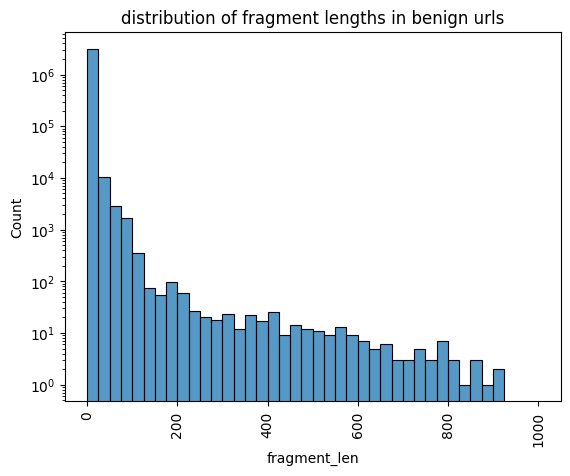

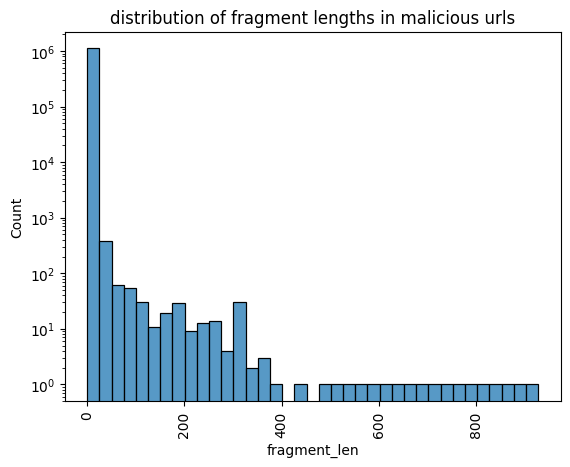

In [226]:
sns.histplot(data=benign_df, x='fragment_len', binrange=[0, 1000], binwidth=25)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of fragment lengths in benign urls')
plt.show()

sns.histplot(data=malicious_df, x='fragment_len', binwidth=25)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('distribution of fragment lengths in malicious urls')
plt.show()

In [28]:
overlapping_netlocs = set(benign_df['url'].progress_apply(lambda url: urlparse(url).netloc)) & set(malicious_df['url'].progress_apply(lambda url: urlparse(url).netloc))

print(len(overlapping_netlocs))

overlapping_netlocs

100%|██████████| 1118060/1118060 [00:08<00:00, 124385.13it/s]


507


{'0rz.tw',
 '1dollaradz.com',
 '1worldsync.com',
 '2m.ma',
 '3seer.net',
 '3tech.org',
 '69.com',
 '7jigen.net',
 '90secondwebsitebuilder.com',
 'aaxisnano.com',
 'abada.ru',
 'abload.de',
 'abooali.ir',
 'about.me',
 'abvp.com',
 'accevate.com',
 'accounts.google.com',
 'acidmods.com',
 'acrobat.adobe.com',
 'ad.doubleclick.net',
 'aeonbig.com.my',
 'agiazoni.gr',
 'aitatennis.com',
 'ajpojournals.org',
 'akmos.com.br',
 'alamdi.net',
 'alfafile.net',
 'aliah.ac.in',
 'alkhebradriving.com',
 'allmylike.com',
 'allowcopy.com',
 'alocidade.com.br',
 'amclicks.com',
 'amfacilities.com',
 'ample.co.in',
 'amtvmedia.com',
 'andares.com',
 'ankos.gen.tr',
 'anpad.org.br',
 'ansaluniversity.edu.in',
 'aosorwell.com',
 'aphriapub.com',
 'apjor.com',
 'apkpure.com',
 'app.getresponse.com',
 'app.loanspq.com',
 'app.powerbi.com',
 'apps.apple.com',
 'aprendapianoen3meses.com',
 'arabsong.net',
 'archive.org',
 'ars.electronica.art',
 'asialiveaction.com',
 'askit.ro',
 'atbu.edu.ng',
 'autosoft

In [29]:
benign_df['sub_domain'] = benign_df['url'].progress_apply(lambda url: tldextract.extract(urlparse(url).netloc).subdomain)
malicious_df['sub_domain'] = malicious_df['url'].progress_apply(lambda url: tldextract.extract(urlparse(url).netloc).subdomain)

100%|██████████| 1118060/1118060 [00:20<00:00, 55466.66it/s]


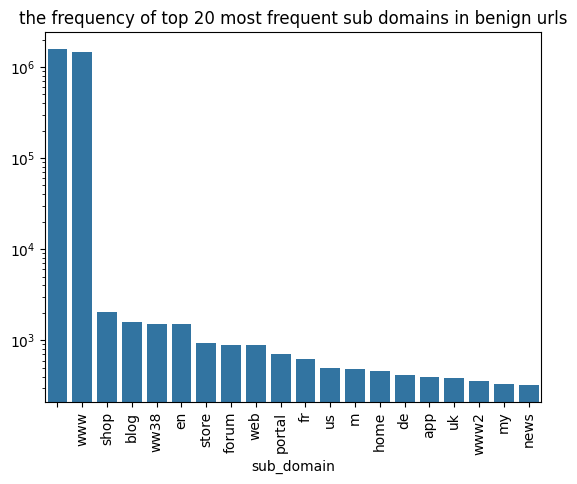

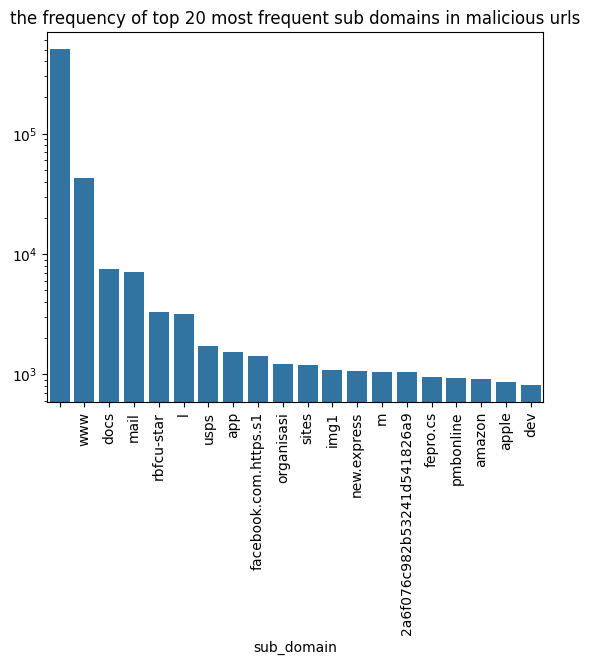

In [30]:
benign_sub_domain_freq = benign_df['sub_domain'].value_counts()
sns.barplot(
	x=benign_sub_domain_freq.head(20).index,
	y=benign_sub_domain_freq.head(20).values,
)

plt.yscale('log')
plt.xticks(rotation=90)
plt.title('the frequency of top 20 most frequent sub domains in benign urls')
plt.show()

malicious_sub_domain_freq = malicious_df['sub_domain'].value_counts()
sns.barplot(
	x=malicious_sub_domain_freq.head(20).index,
	y=malicious_sub_domain_freq.head(20).values,
)

plt.yscale('log')
plt.title('the frequency of top 20 most frequent sub domains in malicious urls')
plt.xticks(rotation=90)
plt.show()

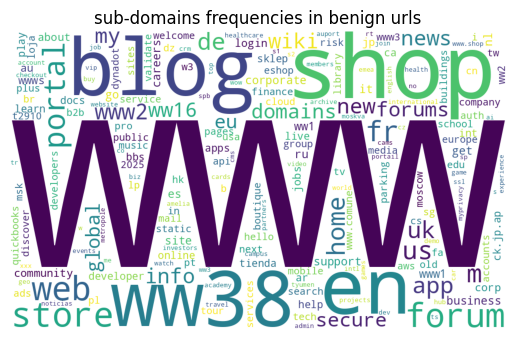

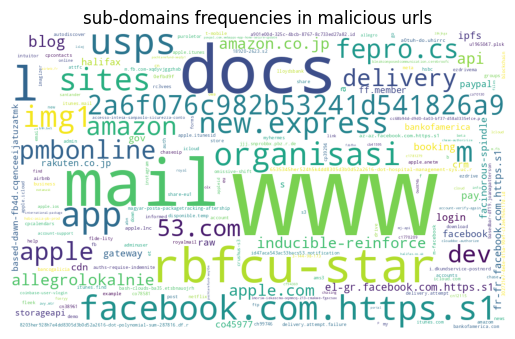

In [31]:
benign_wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(benign_sub_domain_freq)

plt.title('sub-domains frequencies in benign urls')
plt.imshow(benign_wordcloud)
plt.axis("off")
plt.show()

malicious_wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(malicious_sub_domain_freq)

plt.title('sub-domains frequencies in malicious urls')
plt.imshow(malicious_wordcloud)
plt.axis("off")
plt.show()

In [32]:
benign_df['domain'] = benign_df['url'].progress_apply(lambda url: tldextract.extract(urlparse(url).netloc).domain)
malicious_df['domain'] = malicious_df['url'].progress_apply(lambda url: tldextract.extract(urlparse(url).netloc).domain)

100%|██████████| 1118060/1118060 [00:15<00:00, 71704.55it/s]


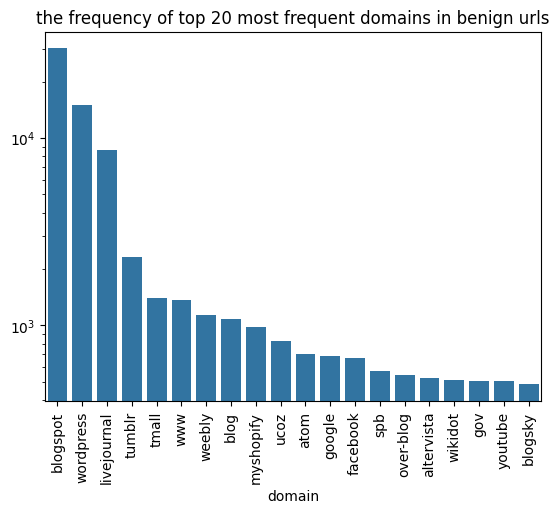

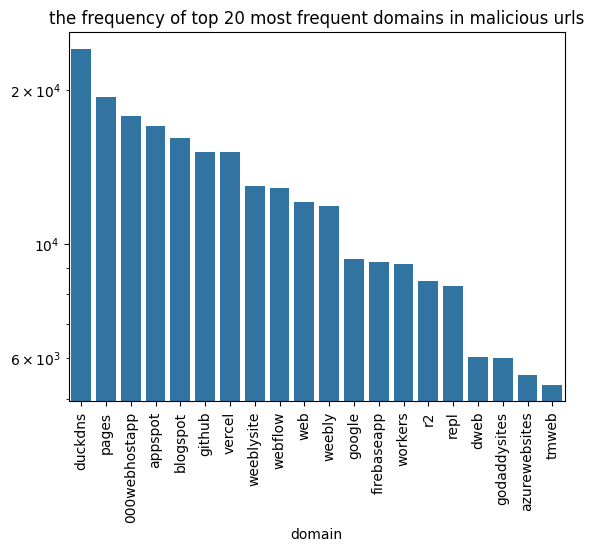

In [33]:
benign_domain_freq = benign_df['domain'].value_counts()
sns.barplot(
	x=benign_domain_freq.head(20).index,
	y=benign_domain_freq.head(20).values,
)

plt.yscale('log')
plt.xticks(rotation=90)
plt.title('the frequency of top 20 most frequent domains in benign urls')
plt.show()

malicious_domain_freq = malicious_df['domain'].value_counts()
sns.barplot(
	x=malicious_domain_freq.head(20).index,
	y=malicious_domain_freq.head(20).values,
)

plt.yscale('log')
plt.title('the frequency of top 20 most frequent domains in malicious urls')
plt.xticks(rotation=90)
plt.show()

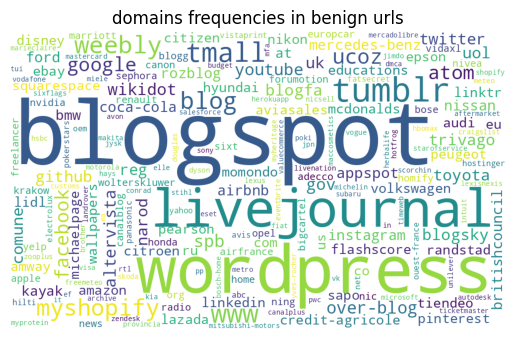

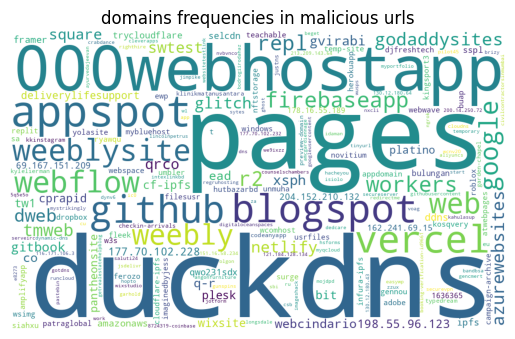

In [34]:
benign_wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(benign_domain_freq)

plt.title('domains frequencies in benign urls')
plt.imshow(benign_wordcloud)
plt.axis("off")
plt.show()

malicious_wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(malicious_domain_freq)

plt.title('domains frequencies in malicious urls')
plt.imshow(malicious_wordcloud)
plt.axis("off")
plt.show()

In [35]:
benign_df['tld'] = benign_df['url'].progress_apply(lambda url: tldextract.extract(urlparse(url).netloc).suffix)
malicious_df['tld'] = malicious_df['url'].progress_apply(lambda url: tldextract.extract(urlparse(url).netloc).suffix)

100%|██████████| 1118060/1118060 [00:15<00:00, 70900.16it/s]


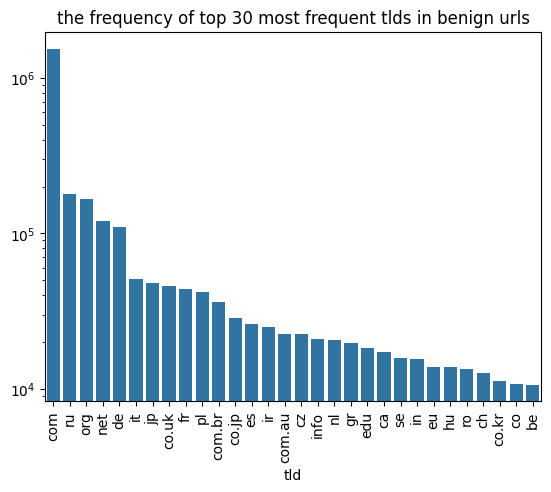

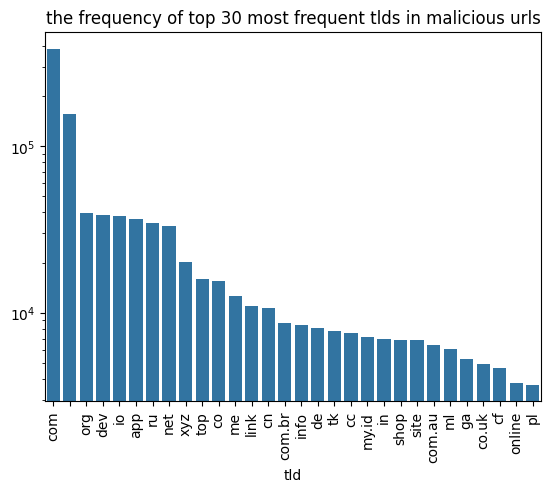

In [36]:
benign_tld_freq = benign_df['tld'].value_counts()
sns.barplot(
	x=benign_tld_freq.head(30).index,
	y=benign_tld_freq.head(30).values,
)

plt.yscale('log')
plt.xticks(rotation=90)
plt.title('the frequency of top 30 most frequent tlds in benign urls')
plt.show()

malicious_tld_freq = malicious_df['tld'].value_counts()
sns.barplot(
	x=malicious_tld_freq.head(30).index,
	y=malicious_tld_freq.head(30).values,
)

plt.yscale('log')
plt.title('the frequency of top 30 most frequent tlds in malicious urls')
plt.xticks(rotation=90)
plt.show()

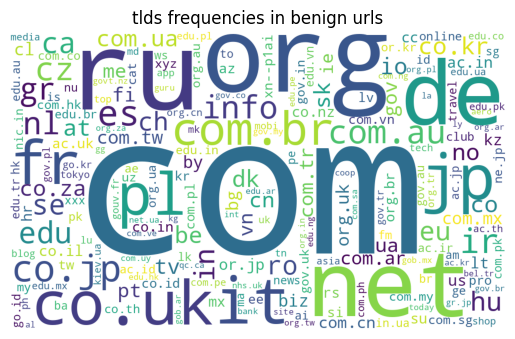

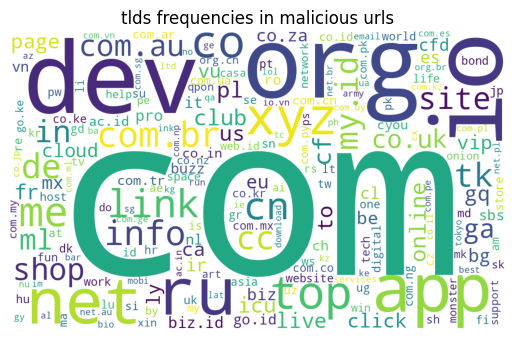

In [37]:
benign_wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(benign_tld_freq)

plt.title('tlds frequencies in benign urls')
plt.imshow(benign_wordcloud)
plt.axis("off")
plt.show()

malicious_wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(malicious_tld_freq)

plt.title('tlds frequencies in malicious urls')
plt.imshow(malicious_wordcloud)
plt.axis("off")
plt.show()